In [ ]:
#All relevant imports for the notebook
import pandas as pd
import matplotlib.pyplot as plt
import requests
import datetime
from datetime import datetime
import sqlite3
import numpy as np
import seaborn as sns
from scipy import stats

# **Does production budget significantly predict box office revenue, and is there evidence of diminishing marginal returns as production budgets increase, after controlling for genre and audience rating?**

As the film industry spans projects ranging from low-budget independent films to high-budget blockbusters, an interesting question is whether and how production budget affects box office performance.

Such an explanatory analysis may support **film studios** and **producers** in making **more informed budgeting** and **investment decisions**, particularly when allocating resources to large-scale productions. In this context, we explore the relationship between production budget and box office revenue, with particular attention to whether increased investment continues to yield proportional gains in revenue as budgets rise.

We further recognize that box office performance may be influenced by other factors. Specifically, genre reflects variation in audience appeal, whereas audience rating indicates post-release reception. Therefore, in this study, we account for genre and audience rating to **isolate the independent effect** of production budget on box office revenue.

## **Hypothesis/Analysis Goal (Ask)**





While higher budgets are commonly associated with greater commercial success, this relationship may not be strictly linear. In particular, films with very high production budgets may experience diminishing marginal returns, where additional investment leads to proportionally smaller increases in revenue.

We aim to conduct a **regression-based analysis** to examine the relationship between production budget and box office revenue, while **controlling for genre and audience rating** as confounding factors. We hypothesize that production budget is a statistically significant predictor of box office revenue, but that the marginal effect of budget decreases at higher budget levels.

The analysis will assess **(1) the significance and direction of the budget–revenue relationship**, **(2) evidence of non-linearity or diminishing returns while controlling for genre and audience rating.** Model performance will be evaluated using appropriate regression diagnostics.


## **Data Source Identification and Exploration (Prepare)**

### **Requirement Analysis.**
To tackle this problem, we need datasets of films that includes information on **box office revenue, production budget**. These data need to aligned with **genre **and** audience rating**. Box office revenue serves as the primary outcome variable, while production budget is the main explanatory variable of interest.

For analysis, it is desirable to have films covering a **wide range** of production budgets, from low-budget to high-budget productions, in order to detect potential diminishing marginal returns. Similarly, the dataset should include **sufficient representation** across different genres and audience rating levels to allow for proper control of these factors.

It is sufficient to have one summary entry per film, as the analysis focuses on **overall** commercial performance rather than detailed dynamics during a film’s theatrical run. Since box office revenue reflects aggregated audience response after release, fine-grained time-series data is **not required**. Each film can therefore be treated as **an independent observation** with summary-level attributes.

### **List of considered sources.**
In the following, we outline several sources we considered and explored and justify the final source selection, in particular based on concepts discussed in class.

*   **Primary Data Sources (used for modeling)**
  * [TMDB 5000 Movie Dataset (DS1)](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata?select=tmdb_5000_movies.csv)
  * [Movies Box office Dataset (2000-2024) (DS2)](https://www.kaggle.com/datasets/aditya126/movies-box-office-dataset-2000-2024)
*   **Validation Data Source**
  * [IMDB Dataset (DS3)](https://datasets.imdbws.com/)
*   **Excluded Dataset**
  * [Ratings_small Dataset (DS4)](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset/data?select=ratings_small.csv)
  



### **Dataset Selection Justification**

**Coverage**

*   DS1 (TMDB 5000) serves as our **foundational metadata source**, providing base financial figures and genre information required for our control variables.

*   DS2 (Box Office 2000-2024) focuses specifically on the modern theatrical part, contributing **highly detailed and varied worldwide revenue data**.

*   DS3 (IMDb Ratings) provides an unparalleled, **massive** repository of audience reception.

By combining these, we comprehensively cover our required dimensions: financial inputs (budget), financial outputs (revenue), categorical controls (genres), and audience controls (ratings).


**Alignment:** **All** three datasets treat a single movie as **an independent observation**. They also share **common identifiers** (eg. movie titles and release years) allowing for deterministic merging across financial records and audience metrics without losing the core entity level.


**Reliability:** TMDB and IMDb are **globally recognized**, **industry-standard databases** for cinematic metadata and audience sentiment. **Cross-referencing** financial data between DS1 and DS2 shows high consistency (e.g., both capture the maximum worldwide revenue at approximately $2.79 billion). This cross-validation ensures the financial figures fed into our regression model are robust and reliable.

We **excluded dataset 4** for the following reasons:


- The dataset **does not contain** key variables required for our research question (e.g., budget and revenue).
- The data structure would require aggregation from user-level to film-level, introducing **additional complexity**.
- Matching `movieId` across different datasets may also lead to **inconsistencies** without a unified identifier system.

Therefore, while this dataset may be useful for analyzing user preferences or building recommendation systems, it is not aligned with the objectives of our study and is excluded from the final dataset selection.

// *GAI helped generate a first text*

### **Presenting essential characteristics of the data.**

#### **Reading TMDB 5000 Movie Dataset (DS1).**

For dataset 1, we ingested the raw TMDB metadata file and conducted an **initial quality assessment**. The core variables required for our analysis (budget, revenue, vote_average, vote_count) **exist with zero missing values.**

We obtained a foundational, film-level data frame of 4,803 observations and 20 variables, characterized by high financial variance (revenues up to $2.78B).

In [ ]:
tmdb_movies = pd.read_csv("sample_data/tmdb_5000_movies.csv")
tmdb_movies.head()
#GAI helped to convert the path from Drive to sample_data



,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [ ]:
tmdb_movies.shape


(4803, 20)

In [ ]:
tmdb_movies.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

**Summary statistics.**

In [ ]:
tmdb_movies[['budget','revenue','vote_average','vote_count']].describe()


,budget,revenue,vote_average,vote_count
count,4.803000e+03,4.803000e+03,4803.000000,4803.000000
mean,2.904504e+07,8.226064e+07,6.092172,690.217989
std,4.072239e+07,1.628571e+08,1.194612,1234.585891
min,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,7.900000e+05,0.000000e+00,5.600000,54.000000
50%,1.500000e+07,1.917000e+07,6.200000,235.000000
75%,4.000000e+07,9.291719e+07,6.800000,737.000000
max,3.800000e+08,2.787965e+09,10.000000,13752.000000


In [ ]:
tmdb_movies.isnull().sum().sort_values(ascending=False).head(10)


,0
homepage,3091
tagline,844
overview,3
runtime,2
release_date,1
id,0
budget,0
genres,0
original_title,0
popularity,0


**Initial Data Characteristics.** The TMDB 5000 dataset contains **4,803 movies **and** 20 variables**, where each row represents one film.

Key variables such as budget, revenue, vote_average, and vote_count are fully observed with **no missing values**. The financial data exhibits substantial dispersion—budgets range up to to **380 million**, and revenues reach up to **2.78 billion**. Budget and revenue show substantial variation, indicating **sufficient dispersion** to examine potential diminishing returns.

Missing values mainly appear in non-essential metadata fields (e.g., homepage and tagline) and **do not affect** our main analysis variables.

Overall, the dataset provides adequate scale, variability, and completeness for our research question.

#### **Reading Movies Box office Dataset (2000-2024) (DS2).**

For dataset 2, we loaded it to capture modern, real-world **financial performance**. The initial processing involved **verifying the integrity** and **dispersion of the worldwide box office figures** to ensure they **complement** the financial data in DS1.

We extracted a film-level data frame containing **5,000 observations and 13 variables.** It gives high-variance **financial and language metrics** (revenue ranging from 1.66M to 2.79B) ready for subsequent merging and regression analysis.

In [ ]:
box_office = pd.read_csv("sample_data/enhanced_box_office_data(2000-2024)u.csv")
box_office.head()


,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


The Movies Box Office Dataset (2000–2024) contains **5,000 films and 13 variables**. Worldwide revenue ranges from **1.66M to 2.79B USD** (Mean: 119.2M, SD: 200.5M), showing strong variation and **complementing the financial data in DS1.** The dataset includes financial, genre, and language information, making it suitable for revenue **analysis** and **merging** with other sources.


In [ ]:
box_office.shape


(5000, 13)

In [ ]:
box_office['$Worldwide'].describe()



,$Worldwide
count,5.000000e+03
mean,1.192137e+08
std,2.005243e+08
min,1.666028e+06
25%,2.466220e+07
50%,4.844658e+07
75%,1.197588e+08
max,2.799439e+09


#### **Reading IMDB Ratings Dataset (DS3).**


For dataset 3, we imported massive, raw TSV files directly from IMDb, consisting of a **base metadata table (12.4 million rows)** and a **ratings table (1.65 million rows)**. Because the raw data contained a mix of TV episodes, shorts, and video games, we performed a **strict filtering operation**, restricting the dataset to **only** rows where titleType == "movie".

Through this filtering process, we **transformed** a heavily mixed database into a **film-level structure** containing 741,038 **pure** feature film records alongside their **corresponding audience ratings**, aligning the dataset's granularity with our TMDB and Box Office data.

In [ ]:
!wget -q https://datasets.imdbws.com/title.basics.tsv.gz
!wget -q https://datasets.imdbws.com/title.ratings.tsv.gz
!ls


sample_data	     title.basics.tsv.gz.1  title.ratings.tsv.gz.1
title.basics.tsv.gz  title.ratings.tsv.gz   tmdb_5000_credits.csv


In [ ]:
imdb_basics = pd.read_csv(
    "title.basics.tsv.gz",
    sep="\t",
    na_values="\\N",
    usecols=["tconst", "titleType", "primaryTitle", "startYear", "genres"]
)

imdb_ratings = pd.read_csv(
    "title.ratings.tsv.gz",
    sep="\t",
    na_values="\\N"
)

imdb_basics.head()
imdb_ratings.head()



,tconst,averageRating,numVotes
0,tt0000001,5.7,2201
1,tt0000002,5.5,312
2,tt0000003,6.4,2314
3,tt0000004,5.1,197
4,tt0000005,6.2,3039


**Dataset structure.**

In [ ]:
imdb_basics.info()
imdb_ratings.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12418169 entries, 0 to 12418168
Data columns (total 5 columns):
 #   Column        Dtype  
---  ------        -----  
 0   tconst        object 
 1   titleType     object 
 2   primaryTitle  object 
 3   startYear     float64
 4   genres        object 
dtypes: float64(1), object(4)
memory usage: 473.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657607 entries, 0 to 1657606
Data columns (total 3 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   tconst         1657607 non-null  object 
 1   averageRating  1657607 non-null  float64
 2   numVotes       1657607 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 37.9+ MB


**Dataset scale.**

In [ ]:
imdb_basics.shape
imdb_ratings.shape


(1657607, 3)

**Summary statistics.**

In [ ]:
imdb_ratings.describe()


,averageRating,numVotes
count,1.657607e+06,1.657607e+06
mean,6.960856e+00,1.038457e+03
std,1.418144e+00,1.818219e+04
min,1.000000e+00,5.000000e+00
25%,6.200000e+00,1.200000e+01
50%,7.200000e+00,2.700000e+01
75%,7.900000e+00,1.030000e+02
max,1.000000e+01,3.175485e+06


**Filtering IMDb to movie titles only.** The IMDb dataset **contains multiple title types**, including short films, TV series, video games, and others. To ensure consistency with the TMDB dataset (which focuses on movies), we restrict the dataset to entries where `titleType == "movie"`.


In [ ]:
imdb_basics['titleType'].value_counts().head(10)


,count
titleType,
tvEpisode,9589331
short,1123583
movie,742570
video,324154
tvSeries,297460
tvMovie,154483
tvMiniSeries,69369
tvSpecial,57631
videoGame,48620


In [ ]:
imdb_movies = imdb_basics[imdb_basics['titleType'] == 'movie']
imdb_movies.shape


(742570, 5)

#### **Reading Ratings_small Dataset (DS4).**

For dataset 4, we conducted an exploratory **read** of this dataset to evaluate its potential **contribution to our audience reception metrics**. However, upon inspecting the data structure (userId, movieId, rating, timestamp), we noticed a fundamental **misalignment in data granularity**.

We found that the dataset consists of approximately 100,000 **user-rating-level observations**, rather than film-level observations. Because our core analytical pipeline requires macro-level financial and characteristic data aggregated **per film**, this dataset is structurally **incompatible** and **excluded** from further integration.

In [ ]:
ratings_small = pd.read_csv("sample_data/ratings_small.csv")
ratings_small.head()
ratings_small.info()
ratings_small.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


,userId,movieId,rating,timestamp
count,100004.000000,100004.000000,100004.000000,1.000040e+05
mean,347.011310,12548.664363,3.543608,1.129639e+09
std,195.163838,26369.198969,1.058064,1.916858e+08
min,1.000000,1.000000,0.500000,7.896520e+08
25%,182.000000,1028.000000,3.000000,9.658478e+08
50%,367.000000,2406.500000,4.000000,1.110422e+09
75%,520.000000,5418.000000,4.000000,1.296192e+09
max,671.000000,163949.000000,5.000000,1.476641e+09


Dataset 4 (`ratings_small.csv`) containing user-level movie ratings.

From the dataset structure, we observe that it consists of **approximately 100,000 observations** with variables such as `userId`, `movieId`, `rating`, and `timestamp`. This indicates that the unit of observation is at the **user–rating level** rather than the film level.

It is **not directly compatible** with our analysis, which focuses on **film-level characteristics** such as production budget, box office revenue, and genre.

## **Data Processing**



Before conducting the analysis, several preprocessing steps were applied to clean and integrate the datasets.

First, movie titles and release years were **standardized** to ensure **consistent matching** across datasets. These cleaned identifiers were then used to **merge the TMDB dataset** with the box office dataset.

Next, the genre information from TMDB was processed. The original `genres` field is stored as a JSON-like string and may contain multiple genres for a single movie. We **extracted** the genre names and **converted them into** **dummy variables** **(0/1 indicators)**, allowing genre information to be incorporated into regression analysis.

These preprocessing steps produce a structured dataset that combines production budget, box office revenue, audience ratings, and genre indicators for each film.

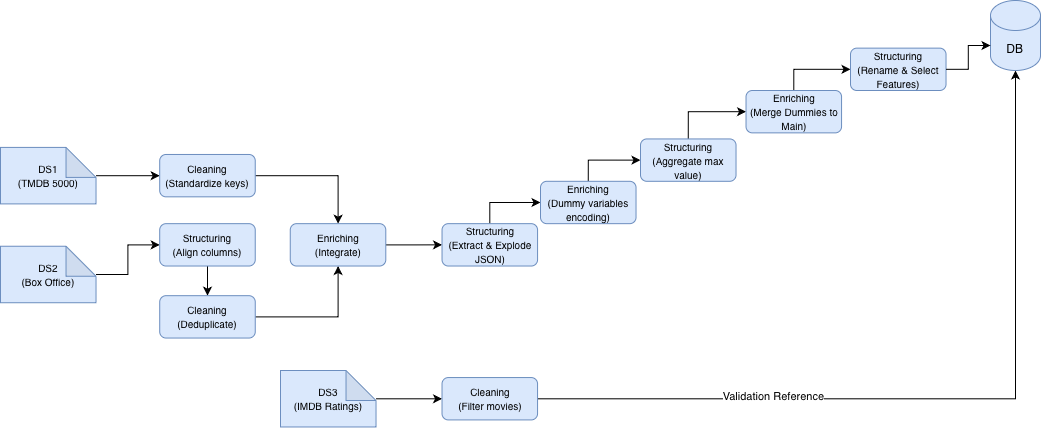

### **Dataset Standardization and Cleaning**

In this step, we **standardize** key variables across datasets to ensure consistent and reliable merging.

**For the TMDB dataset**, movie **titles** are cleaned and release years are extracted to construct matching keys.  
**For the box office dataset**, **column names** are aligned, titles are processed using the same method, and duplicate records are removed.

These steps are used to **minimize mismatches** during merging, especially given variations in naming conventions and formatting across different data sources.

As a result, we obtain a consistent and structured dataset that allows accurate integration of budget, revenue, ratings, and genre information at the film level.


In [ ]:
import re

def clean_title(x):
    if pd.isna(x):
        return x
    x = str(x).lower().strip()
    x = x.replace("&", "and")
    x = re.sub(r"[^\w\s]", "", x)
    x = re.sub(r"\s+", " ", x)
    return x

In [ ]:
tmdb = tmdb_movies[['title','release_date','budget','revenue','vote_average','vote_count','genres']].copy()
tmdb['release_year'] = pd.to_datetime(tmdb['release_date'], errors='coerce').dt.year
tmdb['release_year'] = tmdb['release_year'].astype('Int64')
tmdb[['title','release_year']].head()

,title,release_year
0,Avatar,2009
1,Pirates of the Caribbean: At World's End,2007
2,Spectre,2015
3,The Dark Knight Rises,2012
4,John Carter,2012


In [ ]:
tmdb['title_clean'] = tmdb['title'].apply(clean_title)

In [ ]:
tmdb = tmdb[(tmdb['budget'] > 0) & (tmdb['revenue'] > 0)]

In [ ]:
box = box_office.copy()

box = box.rename(columns={
    'Release Group': 'title',
    'Year': 'release_year',
    '$Worldwide': 'worldwide_revenue',
    'Genres': 'genres_box',
    'Rating': 'rating_box',
    'Vote_Count': 'vote_count_box'
})

box.head()

,Rank,title,worldwide_revenue,$Domestic,Domestic %,$Foreign,Foreign %,release_year,genres_box,rating_box,vote_count_box,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


In [ ]:
box['title_clean'] = box['title'].apply(clean_title)
box['release_year'] = pd.to_numeric(box['release_year'], errors='coerce').astype('Int64')

In [ ]:
box = box.drop_duplicates(subset=['title_clean', 'release_year'])

In [ ]:
tmdb[['title', 'title_clean', 'release_year']].head(10)


,title,title_clean,release_year
0,Avatar,avatar,2009
1,Pirates of the Caribbean: At World's End,pirates of the caribbean at worlds end,2007
2,Spectre,spectre,2015
3,The Dark Knight Rises,the dark knight rises,2012
4,John Carter,john carter,2012
5,Spider-Man 3,spiderman 3,2007
6,Tangled,tangled,2010
7,Avengers: Age of Ultron,avengers age of ultron,2015
8,Harry Potter and the Half-Blood Prince,harry potter and the halfblood prince,2009
9,Batman v Superman: Dawn of Justice,batman v superman dawn of justice,2016


In [ ]:
box[['title', 'title_clean', 'release_year']].head(10)

,title,title_clean,release_year
0,Mission: Impossible II,mission impossible ii,2000
1,Gladiator,gladiator,2000
2,Cast Away,cast away,2000
3,What Women Want,what women want,2000
4,Dinosaur,dinosaur,2000
5,How the Grinch Stole Christmas,how the grinch stole christmas,2000
6,Meet the Parents,meet the parents,2000
7,The Perfect Storm,the perfect storm,2000
8,X-Men,xmen,2000
9,What Lies Beneath,what lies beneath,2000


### **Merge Datasets (ds1 & ds2)**

In [ ]:
box_merge = box[[
    'title_clean',
    'release_year',
    'worldwide_revenue',
    'rating_box',
    'vote_count_box'
]].copy()

merged = tmdb.merge(
    box_merge,
    on=['title_clean', 'release_year'],
    how='left'
)

print("TMDB rows:", len(tmdb))
print("Merged rows:", len(merged))
print("Matched rows:", merged['worldwide_revenue'].notna().sum())
print("Match rate:", merged['worldwide_revenue'].notna().mean())

TMDB rows: 3229
Merged rows: 3229
Matched rows: 1749
Match rate: 0.5416537627748529


In [ ]:
merged[[
    'title',
    'release_year',
    'revenue',
    'worldwide_revenue',
    'vote_average',
    'rating_box',
    'vote_count',
    'vote_count_box'
]].head(10)

,title,release_year,revenue,worldwide_revenue,vote_average,rating_box,vote_count,vote_count_box
0,Avatar,2009,2787965087,2.743578e+09,7.2,7.583/10,11800,31654.0
1,Pirates of the Caribbean: At World's End,2007,961000000,9.609965e+08,6.9,7.257/10,4500,14375.0
2,Spectre,2015,880674609,8.806746e+08,6.3,6.6/10,4466,10515.0
3,The Dark Knight Rises,2012,1084939099,1.084939e+09,7.6,7.8/10,9106,22803.0
4,John Carter,2012,284139100,2.841391e+08,6.1,6.323/10,2124,5608.0
5,Spider-Man 3,2007,890871626,8.908716e+08,5.9,6.432/10,3576,14153.0
6,Tangled,2010,591794936,5.917949e+08,7.4,7.604/10,3330,11513.0
7,Avengers: Age of Ultron,2015,1405403694,1.402806e+09,7.3,7.274/10,6767,23046.0
8,Harry Potter and the Half-Blood Prince,2009,933959197,9.339592e+08,7.4,7.688/10,5293,19506.0
9,Batman v Superman: Dawn of Justice,2016,873260194,8.743602e+08,5.7,5.973/10,7004,17998.0


In [ ]:
df_final = merged.copy()

We merge the TMDB dataset with the box office dataset using **standardized movie titles** and **release years** as **matching keys**.

To evaluate the quality of the merge, we compare the number of matched records with the total number of observations. Out of `3,229` movies in the TMDB dataset, **`1,749` were successfully matched** with box office records, resulting in a match rate of **approximately `54%.`**

While this match rate is not perfect, it is considered **acceptable** given potential inconsistencies in movie naming conventions, release year discrepancies, and differences in dataset coverage.

The merged dataset retains **key variables** such as budget, revenue, ratings, and genre information, forming the basis for subsequent regression analysis.

### **Genre Encoding**
The `genres` column in the TMDB dataset is stored as a JSON-like string, where **each movie may belong to multiple genres**.

To incorporate genre information into regression models, these categorical values are **converted into dummy variables (0/1 indicators).**

In [ ]:
import ast

def extract_genres(x):
    try:
        genres = ast.literal_eval(x) # Convert string to Python list
        return [g['name'] for g in genres]   # Extract genre names
    except:
        return []

df_final['genre_list'] = df_final['genres'].apply(extract_genres)

df_final[['title','genre_list']].head()

,title,genre_list
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]"
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]"
2,Spectre,"[Action, Adventure, Crime]"
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]"
4,John Carter,"[Action, Adventure, Science Fiction]"


In [ ]:
df_genre = df_final.explode('genre_list')

In [ ]:
# Convert genre categories into dummy variables (0/1 indicators)
genre_dummies = pd.get_dummies(df_genre['genre_list'], prefix='genre')

### **Transforming and Aggregating Genre Variables**
To transform the genre data into a usable format, we **first extract genre names** and **expand** them into separate rows using `explode()`. This allows each genre to be **processed individually**.

Dummy variables are then generated for each genre. However, after applying `explode()`, a movie may appear multiple times.

To ensure each movie is represented by a single row, we **group the data by movie title** and **take the maximum** value for each dummy variable. This ensures that if a movie belongs to a genre, the corresponding indicator is set to 1.

Finally, the genre dummy variables are **merged back** into the main dataset, allowing genre to be included as independent variables in regression analysis.

In [ ]:
df_genre = pd.concat([df_genre, genre_dummies], axis=1)

genre_final = df_genre.groupby('title').max().reset_index()

df_final = df_final.merge(
    genre_final.drop(columns=['genre_list']),
    on='title',
    how='left'
)

In [ ]:
df_final.filter(like='genre_').head()

,genre_list,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Family,genre_Fantasy,genre_Foreign,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_Thriller,genre_War,genre_Western
0,"[Action, Adventure, Fantasy, Science Fiction]",True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
1,"[Adventure, Fantasy, Action]",True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,"[Action, Adventure, Crime]",True,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,"[Action, Crime, Drama, Thriller]",True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False
4,"[Action, Adventure, Science Fiction]",True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


Overall, this transformation ensures that multi-label categorical information (i.e., movies belonging to multiple genres) is **correctly represented** in a structured, model-ready format.

By first expanding the genre information and then aggregating it back to a single row per movie, we **preserve all genre** **memberships** while **maintaining** the one-observation-per-movie requirement for regression analysis.

The use of dummy variables combined with aggregation allows us to effectively **encode multiple genre affiliations** without introducing duplicate records or bias in the dataset. As a result, the final dataset is both consistent and suitable for statistical modeling.

## **Final Dataset Construction and Modeling Preparation**
    ├── Final Dataset Construction
    ├── Data Quality and Readiness
    └── Log Transformation for Regression

### **Final Dataset Construction**

After merging the datasets and processing genre variables, we construct the **final dataset** used for subsequent analysis.

To improve clarity and consistency, selected variables are **renamed**. We then **retain** **the key variables** required for the study, including budget, revenue, ratings, vote counts, and genre dummy variables.

In [ ]:
df_final = df_final.rename(columns={
    'budget_x': 'budget',
    'revenue_x': 'tmdb_revenue',
    'vote_average_x': 'rating',
    'vote_count_x': 'vote_count',
    'worldwide_revenue_y': 'revenue',
    'rating_box_y': 'rating_box',
    'vote_count_box_y': 'vote_count_box'
})

In [ ]:
df_model = df_final[
    ['title',
     'budget',
     'revenue',
     'rating',
     'vote_count'] +
    [col for col in df_final.columns if col.startswith('genre_') and col != 'genre_list']
]

In [ ]:
df_final.columns

Index(['title', 'release_date_x', 'budget', 'tmdb_revenue', 'rating',
       'vote_count', 'genres_x', 'release_year_x', 'title_clean_x',
       'worldwide_revenue_x', 'rating_box_x', 'vote_count_box_x', 'genre_list',
       'release_date_y', 'budget_y', 'revenue_y', 'vote_average_y',
       'vote_count_y', 'genres_y', 'release_year_y', 'title_clean_y',
       'revenue', 'rating_box', 'vote_count_box', 'genre_Action',
       'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime',
       'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy',
       'genre_Foreign', 'genre_History', 'genre_Horror', 'genre_Music',
       'genre_Mystery', 'genre_Romance', 'genre_Science Fiction',
       'genre_Thriller', 'genre_War', 'genre_Western'],
      dtype='object')

In [ ]:
df_model.columns

Index(['title', 'budget', 'revenue', 'rating', 'vote_count', 'genre_Action',
       'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime',
       'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy',
       'genre_Foreign', 'genre_History', 'genre_Horror', 'genre_Music',
       'genre_Mystery', 'genre_Romance', 'genre_Science Fiction',
       'genre_Thriller', 'genre_War', 'genre_Western'],
      dtype='object')

In [ ]:
df_model[['budget','revenue','rating','vote_count']].describe()

,budget,revenue,rating,vote_count
count,3.229000e+03,1.749000e+03,3229.000000,3229.000000
mean,4.065444e+07,1.712371e+08,6.309353,977.287395
std,4.439674e+07,2.165736e+08,0.873891,1414.309577
min,1.000000e+00,2.019121e+06,0.000000,0.000000
25%,1.050000e+07,4.606185e+07,5.800000,178.000000
50%,2.500000e+07,9.571488e+07,6.300000,471.000000
75%,5.500000e+07,2.008117e+08,6.900000,1148.000000
max,3.800000e+08,2.743578e+09,8.500000,13752.000000


In [ ]:
df_reg = df_model.dropna(subset=['revenue','budget'])
df_reg.shape

(1749, 24)

In [ ]:
df_reg[['budget','revenue','rating','vote_count']].isna().sum()

,0
budget,0
revenue,0
rating,0
vote_count,0


### **Data Quality and Readiness**



After constructing the final dataset and performing necessary cleaning steps, we evaluate its quality and suitability for regression analysis.

#### **1. Merge Quality Assessment**

The merged dataset achieves a **match rate of approximately** **54%**, based on matching movie titles and release years across datasets. This match rate is **reasonable** given variations in title formatting and differences in dataset coverage.

Despite these limitations, the merged dataset remains sufficiently **large** and representative for analysis.

#### **2. Missing Values and Cleaning**

Since revenue is the dependent variable in our regression model, **observations** with missing revenue values **cannot be used**. Budget is also a key explanatory variable, so rows with missing budget values are **removed**.

After removing incomplete observations, we obtain a **cleaned subset** **of data** for regression analysis. A missing-value check confirms that the key numerical variables (budget, revenue, rating, vote count) contain no missing values.

####**3. Final Readiness**

The final dataset is **consistent, complete** for the variables of interest, and suitable for regression modeling.

### **Log Transformation for Regression**



> **Why log transformation?**  
> Budget and revenue are **highly right-skewed** due to the presence of blockbuster films with extremely large values.  
> This skewness can lead to heteroscedasticity and unstable regression estimates.  
>  
> In addition, the log-log specification allows the model to capture **proportional (percentage) relationships** rather than absolute changes.  
> This is because changes in logarithmic values approximate relative changes, as:
>
>$$
\log(x + \Delta x) - \log(x) \approx \frac{\Delta x}{x}
$$
>which corresponds to the **percentage change** in \(x\).
> As a result, **regression coefficients** can be interpreted as **elasticities**, meaning how a 1% change in budget is associated with a percentage change in revenue.  
> This is particularly useful as films **vary greatly in scale**, and percentage-based comparisons provide a **more meaningful** interpretation across movies.

From the summary statistics above, both `log_budget` and `log_revenue` show relatively **compact ranges** and **moderate standard deviations** (around 1.0), indicating that the log transformation has **successfully reduced scale differences** and extreme variation present in the original variables.

Therefore, to **improve the suitability** of the data for regression analysis, we apply a log transformation to the budget and revenue variables.

In summary, by applying a logarithmic transformation:
- We **reduce** the influence of extreme values  
- **Improve the symmetry** of the distributions  
- Make the relationship between budget and revenue **more linear**  

The transformation is applied after data cleaning to ensure valid and consistent inputs.

In [ ]:
df_reg['log_budget'] = np.log1p(df_reg['budget'])
df_reg['log_revenue'] = np.log1p(df_reg['revenue'])

df_reg[['log_budget','log_revenue']].describe()

/tmp/ipykernel_14163/2403138817.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reg['log_budget'] = np.log1p(df_reg['budget'])
/tmp/ipykernel_14163/2403138817.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reg['log_revenue'] = np.log1p(df_reg['revenue'])


,log_budget,log_revenue
count,1749.000000,1749.000000
mean,17.420338,18.407804
std,1.013829,1.044631
min,11.082158,14.518173
25%,16.811243,17.645496
50%,17.504390,18.376884
75%,18.132999,19.117878
max,19.755682,21.732529


##**Data Analysis**

### **Exploratory Data Analysis and Visualization**
    ├── log(Budget) vs log(Revenue) scatter
    ├── Budget distribution
    └── Revenue by genre boxplot


####**1.  log(Budget) vs log(Revenue) scatter**

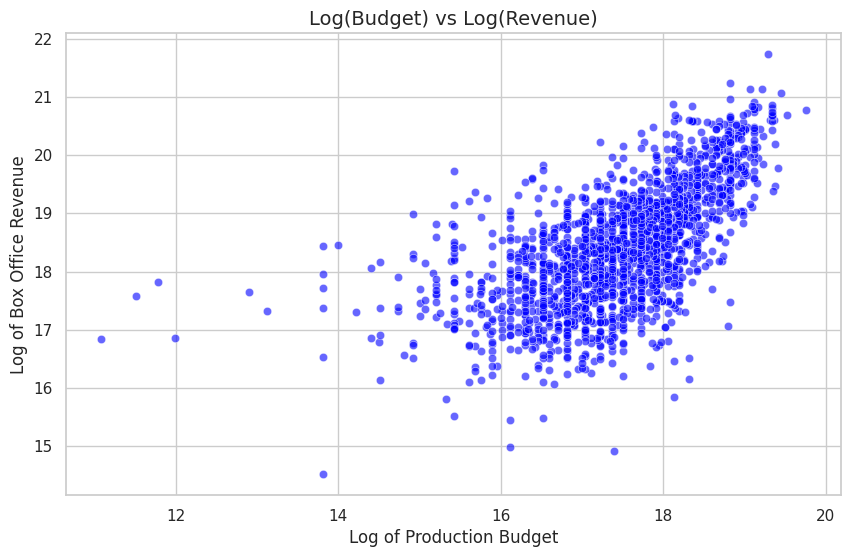

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_reg, x='log_budget', y='log_revenue', alpha=0.6, color='blue')

plt.title('Log(Budget) vs Log(Revenue)', fontsize=14)
plt.xlabel('Log of Production Budget', fontsize=12)
plt.ylabel('Log of Box Office Revenue', fontsize=12)
plt.show()

**Interpretation:**

The scatter plot shows a clear **positive relationship** between log-transformed budget and log-transformed revenue. This suggests that films with higher production budgets tend to generate higher box office revenue.

The use of a log-log scale **reduces the impact of extreme values** and reveals a more linear pattern compared to the raw scale. This **supports the assumption** of a multiplicative relationship between budget and revenue.

Additionally, the relatively **tight clustering of points** along an upward trend indicates that budget is a strong predictor of revenue, although some variability remains due to other factors such as genre and audience reception.

Overall, this visualization provides **preliminary** evidence that a log-log regression model is suitable for analyzing the relationship between budget and revenue.

####**2. Budget distribution**

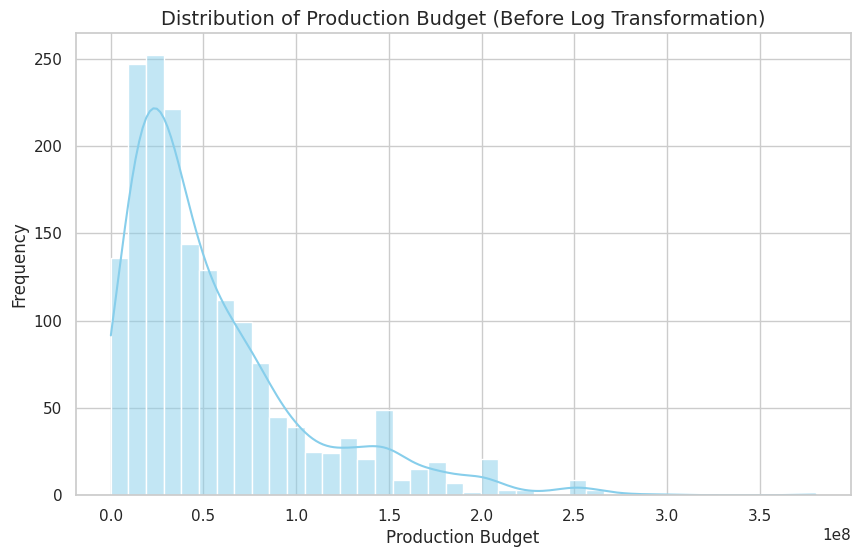

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_reg, x='budget', bins=40, kde=True, color='skyblue')

plt.title('Distribution of Production Budget (Before Log Transformation)', fontsize=14)
plt.xlabel('Production Budget', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

**Interpretation:**

The distribution of production budgets is **highly right-skewed**, with a large number of films having relatively low budgets and a small number of films with extremely high budgets.

This skewness indicates the presence of **outliers** and a non-normal distribution, which can violate the assumptions of linear regression if left untransformed.

The heavy right tail suggests that a few blockbuster films dominate the **upper range of budgets**, while most films operate at a much lower scale.

This observation justifies the use of a logarithmic transformation on the budget variable, as it helps to reduce skewness, stabilize variance, and improve the linearity of relationships in subsequent regression analysis.

####**3. Revenue by genre boxplot**

/tmp/ipykernel_14163/3128439378.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='genre', y='revenue', order=order, palette='Set2')


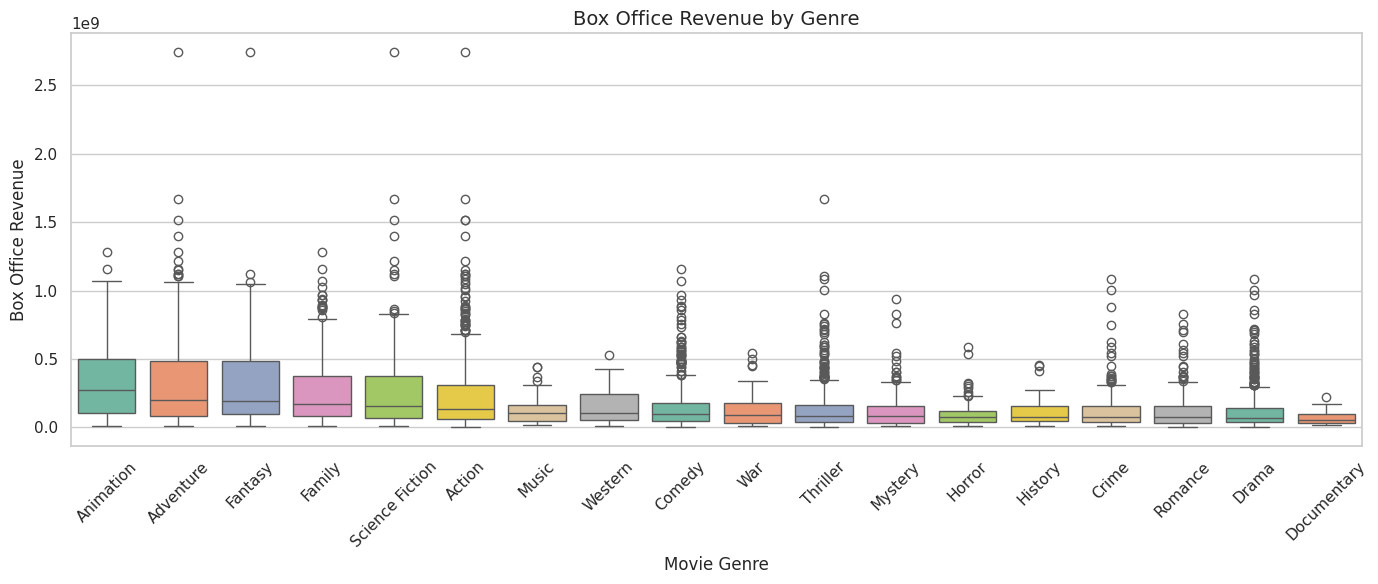

In [ ]:
genre_cols = [col for col in df_reg.columns if col.startswith('genre_')]


df_melted = df_reg.melt(id_vars=['revenue'],
                        value_vars=genre_cols,
                        var_name='genre',
                        value_name='has_genre')

df_plot = df_melted[df_melted['has_genre'] == 1].copy()

df_plot['genre'] = df_plot['genre'].str.replace('genre_', '')


plt.figure(figsize=(14, 6))

order = df_plot.groupby('genre')['revenue'].median().sort_values(ascending=False).index

sns.boxplot(data=df_plot, x='genre', y='revenue', order=order, palette='Set2')

plt.title('Box Office Revenue by Genre', fontsize=14)
plt.xlabel('Movie Genre', fontsize=12)
plt.ylabel('Box Office Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:**

The boxplot illustrates the distribution of box office revenue **across different movie genres**. There is substantial variation both within and across genres.

Certain genres, such as Action, Adventure, and Science Fiction, tend to exhibit **higher median** revenues and wider variability, suggesting greater commercial potential but also higher risk.

In contrast, genres such as Drama and Documentary generally show **lower median revenues** and **less dispersion**, indicating more **modest** but **stable** performance.

The presence of numerous outliers across genres highlights the unpredictability of box office success, where a small number of films significantly outperform the rest.

These differences suggest that genre may play an important role in explaining revenue variation, justifying why it is included as a categorical variable in the regression model.

### **Regression modeling**

In [ ]:
import statsmodels.api as sm


#### **Model 1: Baseline Regression Model.**

We first estimate a **baseline regression model** to examine the relationship between production budget and box office revenue.

Because both variables are highly skewed, we use log-transformed variables in the regression model:

$$
\log(\text{Revenue}_i) = \beta_0 + \beta_1 \log(\text{Budget}_i) + \epsilon_i
$$

In this specification, β₁ represents the **elasticity of revenue** with respect to budget, meaning the percentage change in revenue associated with a 1% increase in budget.

In [ ]:

X = df_reg[['log_budget']]
X = sm.add_constant(X)

y = df_reg['log_revenue']

model1 = sm.OLS(y, X).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.394
Method:                 Least Squares   F-statistic:                     1138.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          1.53e-192
Time:                        13:38:02   Log-Likelihood:                -2118.9
No. Observations:                1749   AIC:                             4242.
Df Residuals:                    1747   BIC:                             4253.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1343      0.335     21.313      0.0

The regression results yield the following key insights:

- **Positive Relationship**  
  Production budget has a positive and statistically significant relationship with box office revenue.

- **Elasticity Interpretation**  
  The estimated coefficient for log_budget (**0.647**) implies that a **1% increase in production budget is associated with an approximately 0.65% increase in box office revenue**, holding other factors constant.

- **Diminishing Marginal Returns**  
  Since the elasticity is less than 1, this indicates **diminishing marginal returns to production budget**. While higher budgets increase revenue, the percentage gain grows at a decreasing rate.

- **Model Explanatory Power**  
  The model explains about **39.4% of the variation in box office revenue (R² = 0.394)**, suggesting that production budget alone captures a substantial portion of revenue differences across films.

- **Limitations**  
  However, other factors such as genre, audience ratings, and market conditions are not yet controlled for and may also influence box office performance.

#### **Model 2: Controlling for Audience Rating**

While production budget is an important determinant of box office revenue, movie quality and audience reception may also influence performance. To account for this, we **extend the baseline model** by including the audience rating variable.

The regression specification becomes:

$$
\log(\text{Revenue}_i) =
\beta_0 +
\beta_1 \log(\text{Budget}_i) +
\beta_2 \text{Rating}_i +
\epsilon_i
$$

In this model, the coefficient for `log_budget` captures the elasticity of revenue with respect to budget while controlling for movie quality as reflected by audience ratings.

In [ ]:
X2 = df_reg[['log_budget', 'rating']]
X2 = sm.add_constant(X2)

y = df_reg['log_revenue']

model2 = sm.OLS(y, X2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.463
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     753.4
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          1.24e-236
Time:                        13:38:02   Log-Likelihood:                -2013.5
No. Observations:                1749   AIC:                             4033.
Df Residuals:                    1746   BIC:                             4049.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9210      0.348     14.131      0.0

The regression results provide the following insights:

- **Positive Effects of Budget and Rating**  
  Both production budget and audience rating have a positive and statistically significant relationship with box office revenue.

- **Elasticity of Budget**  
  The coefficient for log_budget (**0.652**) indicates that a **1% increase in production budget is associated with approximately a 0.65% increase in box office revenue**, holding rating constant.

- **Diminishing Marginal Returns**  
  As in Model 1, the elasticity remains below 1, indicating **diminishing marginal returns to production budget**.

- **Impact of Audience Rating**  
  The coefficient for rating (**0.341**) is positive and statistically significant, suggesting that films with higher audience ratings tend to generate higher box office revenues.

- **Improved Model Fit**  
  The explanatory power of the model increases from **R² = 0.394 (Model 1) to R² = 0.463**, indicating that audience rating provides **additional explanatory power** beyond production budget alone.

- **Interpretation**  
  This suggests that part of the variation in box office revenue, previously attributed solely to budget, can be better explained when audience reception is taken into account.

#### **Model 3: Controlling for Genre**

Box office performance may vary across different film genres. However, the dataset contains a large number of genre categories, many of which appear only a small number of times. **Including all genre** indicators would **unnecessarily** increase model **complexity** and produce unstable estimates.


The regression specification becomes:

$$
\log(\text{Revenue}_i)
=
\beta_0
+
\beta_1 \log(\text{Budget}_i)
+
\beta_2 \text{Rating}_i
+
\gamma_k \text{Genre}_{ik}
+
\epsilon_i
$$

To address this issue, we focus on **several major commercial genres**:

> - Action
> - Comedy
> - Drama
> - Animation
> - Adventure
> - Fantasy
> - Horror
> - Thriller
> - All remaining genres are grouped into a single **"Other"** category.

In the regression model, the "Other" category serves as the reference group. The estimated coefficients for each genre therefore **measure the difference** in expected revenue relative to films belonging to other genres.

In [ ]:
main_genres = [
'genre_Action',
'genre_Comedy',
'genre_Drama',
'genre_Animation',
'genre_Adventure',
'genre_Fantasy',
'genre_Horror',
'genre_Thriller'
]

In [ ]:
all_genres = [c for c in df_reg.columns if c.startswith('genre_')]

other_genres = [g for g in all_genres if g not in main_genres]

df_reg['genre_Other'] = df_reg[other_genres].sum(axis=1)
df_reg['genre_Other'] = (df_reg['genre_Other'] > 0).astype(int)

/tmp/ipykernel_14163/1855695468.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reg['genre_Other'] = df_reg[other_genres].sum(axis=1)
/tmp/ipykernel_14163/1855695468.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reg['genre_Other'] = (df_reg['genre_Other'] > 0).astype(int)


In [ ]:
# make sure genre dummies are numeric
for col in main_genres:
    df_reg[col] = df_reg[col].astype(int)

# build model 3
genre_cols = main_genres   # Other is baseline, so we do NOT include genre_Other

X3 = df_reg[['log_budget', 'rating'] + genre_cols].copy()
X3 = X3.astype(float)      # make everything numeric
X3 = sm.add_constant(X3)

y = df_reg['log_revenue'].astype(float)

model3 = sm.OLS(y, X3).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     188.1
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          2.88e-268
Time:                        13:38:02   Log-Likelihood:                -1916.2
No. Observations:                1749   AIC:                             3854.
Df Residuals:                    1738   BIC:                             3915.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               5.1635      0.394     

/tmp/ipykernel_14163/257677136.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reg[col] = df_reg[col].astype(int)
/tmp/ipykernel_14163/257677136.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reg[col] = df_reg[col].astype(int)
/tmp/ipykernel_14163/257677136.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

The regression results yield the following key insights:

- **Interpretation of Genre Coefficients**  
  Some genre coefficients are negative. These coefficients measure the difference in expected revenue relative to the baseline category (the "Other" genre group). A negative coefficient does **not** imply negative revenue; rather, it indicates that films in that genre tend to generate **lower expected revenue compared with the baseline category**, after controlling for budget and audience rating.  
  For example, the negative coefficient for Drama suggests that, on average, drama films earn less box office revenue than films in the reference group.

- **Change in Budget Effect**  
  The estimated coefficient of `log_budget` decreases slightly compared with Model 2 (from around 0.65 to about 0.60). This occurs because, in Model 2, the budget variable partly captures differences that are actually related to film genres. Once genre indicators are included in Model 3, these effects are controlled for separately.

- **Refined Interpretation of Budget Impact**  
  This adjustment suggests that part of the observed relationship between production budget and box office revenue reflects **genre-related differences**, rather than the effect of budget alone. The coefficient **remains positive** and **statistically significant**, indicating that higher production budgets are still strongly associated with higher box office revenue.

- **Diminishing Marginal Returns**  
  As the coefficient of `log_budget` remains below 1, the results continue to support **diminishing marginal returns**: a 1% increase in production budget is associated with an increase in revenue of less than 1%.

#### **Comparison of Regression Models**

To assess how additional control variables influence the relationship between production budget and box office revenue, we compare the results across the three regression models.

- **Model 1** includes only production budget.
- **Model 2** adds audience rating as an additional explanatory variable.
- **Model 3** further controls for genre differences.

This comparison allows us to evaluate two key aspects:
- How the **estimated effect** of production budget **changes** when **additional variables** are introduced  
- Whether the explanatory power of the model **improves** with richer specifications  

In particular, changes in the coefficient of `log_budget` help reveal whether earlier models **may have overstated** its effect due to omitted variables, while increases in \(R^2\) indicate improved model fit.



#### **Regression Model Comparison**

| Variable        | Model 1 | Model 2 | Model 3 |
|----------------|--------|--------|--------|
| log_budget     | 0.647*** | 0.652*** | 0.601*** |
| rating         | —      | 0.341*** | 0.452*** |
| genre controls | —      | —      | Yes     |
| Constant       | Yes    | Yes    | Yes     |
| Observations   | 1749   | 1749   | 1749   |
| R²             | 0.394  | 0.463  | 0.520 |

***Notes**: *** indicates statistical significance at the 1% level.*

### **External Validation Using IMDb Data**

#### **Validation of Rating and Genre Patterns Using IMDb (DS3)**

**1. Purpose of Validation**

Although the IMDb dataset does not contain revenue information, it provides an **external reference** for understanding patterns in movie ratings and genres.

It helps us interpret the regression results more deeply, especially the role of genre and audience ratings.

In [ ]:
imdb_movies_ratings = imdb_movies.merge(imdb_ratings, on="tconst")

In [ ]:
imdb_movies_ratings.shape

(341898, 7)

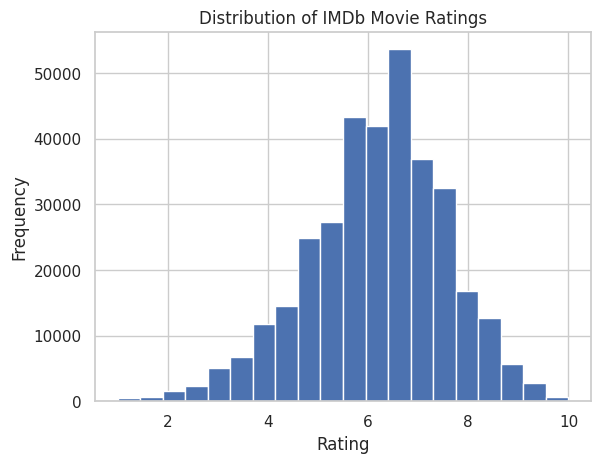

In [ ]:
plt.hist(imdb_movies_ratings["averageRating"], bins=20)

plt.title("Distribution of IMDb Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

**2. Distribution of Ratings**

The histogram above shows that IMDb ratings are approximately **normally distributed**, with most movies receiving ratings between 5 and 7.

This suggests that extreme ratings are **relatively rare**, and audience ratings provide a **meaningful measure** of perceived movie quality.

In [ ]:
genres_exploded = imdb_movies_ratings.assign(genres=imdb_movies_ratings["genres"].str.split(",")) \
                            .explode("genres")

In [ ]:
genre_counts = genres_exploded["genres"].value_counts()

genre_counts.head(10)

,count
genres,
Drama,154914
Comedy,81989
Documentary,55717
Romance,37068
Action,34962
Crime,29571
Thriller,29104
Horror,26497
Adventure,20654


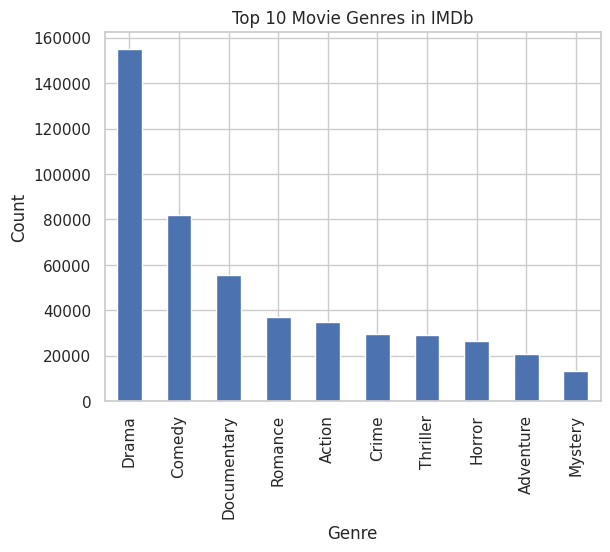

In [ ]:
genre_counts.head(10).plot(kind="bar")

plt.title("Top 10 Movie Genres in IMDb")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

**3. Genre Distribution**

The genre distribution above shows that certain genres such as **Drama and Comedy dominate the dataset**, while others appear less frequently.

This **imbalance** highlights the importance of **grouping less frequent genres** into an "Other" category in the regression model to **avoid overfitting**.

In [ ]:
genre_rating = genres_exploded.groupby("genres")["averageRating"].mean().sort_values(ascending=False)

genre_rating.head(10)

,averageRating
genres,
Game-Show,7.466667
News,7.180617
Documentary,7.178105
Biography,6.919224
Music,6.786603
History,6.769783
Talk-Show,6.700000
Sport,6.632034
Film-Noir,6.465943


In [ ]:
movie_genres = [
    "Drama","Comedy","Action","Romance",
    "Thriller","Horror","Adventure","Crime","Mystery"
]

genre_rating_filtered = genre_rating.loc[genre_rating.index.isin(movie_genres)]

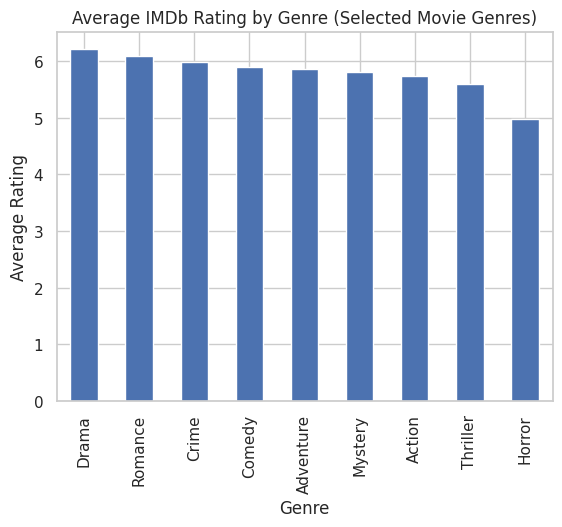

In [ ]:
genre_rating_filtered.plot(kind="bar")

plt.title("Average IMDb Rating by Genre (Selected Movie Genres)")
plt.xlabel("Genre")
plt.ylabel("Average Rating")

plt.show()

**4. Rating Differences Across Genres**

We observe systematic differences in ratings across genres:

- Genres such as **Drama and Romance tend to receive higher ratings**
- Genres such as **Horror generally receive lower ratings**

This indicates that audience perception varies significantly across genres.

#### **Linking Validation to Regression Results.**



Combining these findings with the regression results, we gain additional insights:

- The **positive coefficient for rating** indicates that higher-rated movies tend to generate higher revenue  
- However, genre effects are not fully explained by ratings alone  

>For example:
>- Horror films tend to have **lower ratings**  
>- Yet, the regression results show a **positive genre coefficient for Horror**
>
> This suggests that horror movies can still perform well commercially despite lower perceived quality.
>
>One possible explanation is that horror films often have **lower production budgets and strong audience appeal**, allowing them to be profitable even with moderate ratings.

### **Diminishing Returns to Production Budget**



In Model 3, the coefficient of `log_budget` is approximately **0.6005**. Since both revenue and budget are measured in logarithmic form, this coefficient can be interpreted as an elasticity.

> - A **1% increase in production budget** is associated with an approximately **0.60% increase in box office revenue**, holding rating and genre constant.
>
> - Because this elasticity is **less than 1**, the results indicate that revenue increases at a **slower rate than budget**.
>
> - This provides evidence of **diminishing marginal returns**: while increasing production budget continues to raise revenue, the additional gain becomes proportionally smaller at higher budget levels.

#### **Quadratic Specification for Budget**

To test whether the budget–revenue relationship **becomes weaker at higher budget levels**, we introduce a quadratic term for `log_budget`.

The specification is:

$$
\log(\text{Revenue}_i)
=
\beta_0
+
\beta_1 \log(\text{Budget}_i)
+
\beta_2 \log(\text{Budget}_i)^2
+
\beta_3 \text{Rating}_i
+
\gamma_k \text{Genre}_{ik}
+
\epsilon_i
$$

If the coefficient of the squared term is **negative**, this would provide **stronger** evidence that the effect of budget diminishes as budget increases.

In [ ]:
# Quadratic model to examine diminishing returns more explicitly

df_reg["log_budget_sq"] = df_reg["log_budget"] ** 2

X4 = df_reg[[
    "log_budget",
    "log_budget_sq",
    "rating",
    "genre_Action",
    "genre_Comedy",
    "genre_Drama",
    "genre_Animation",
    "genre_Adventure",
    "genre_Fantasy",
    "genre_Horror",
    "genre_Thriller"
]].copy()

X4 = sm.add_constant(X4)
y = df_reg["log_revenue"]

model4 = sm.OLS(y, X4).fit()

print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.575
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     213.6
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          4.91e-313
Time:                        13:38:05   Log-Likelihood:                -1809.3
No. Observations:                1749   AIC:                             3643.
Df Residuals:                    1737   BIC:                             3708.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              41.1247      2.421     

/tmp/ipykernel_14163/2575196010.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reg["log_budget_sq"] = df_reg["log_budget"] ** 2


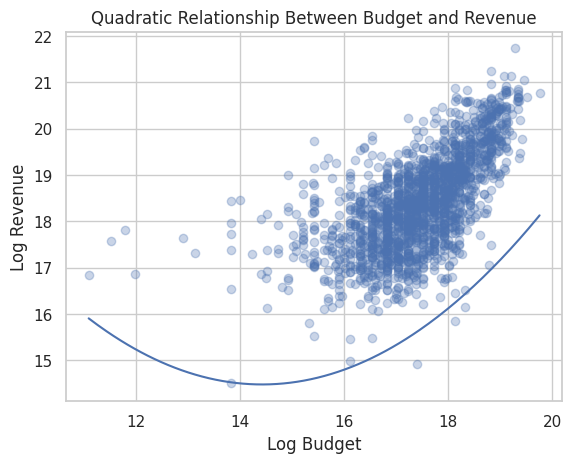

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Scatter plot
plt.scatter(df_reg["log_budget"], df_reg["log_revenue"], alpha=0.3)

# Fitted quadratic curve
x_vals = np.linspace(df_reg["log_budget"].min(), df_reg["log_budget"].max(), 200)
y_vals = (
    model4.params["const"]
    + model4.params["log_budget"] * x_vals
    + model4.params["log_budget_sq"] * (x_vals ** 2)
)

plt.plot(x_vals, y_vals)

plt.xlabel("Log Budget")
plt.ylabel("Log Revenue")
plt.title("Quadratic Relationship Between Budget and Revenue")

plt.show()

**Interpretation：**

The fitted quadratic curve in the figure shows a clear **nonlinear relationship** between budget and revenue.

Consistent with the regression results, the coefficient of `log_budget` is **negative**, while the coefficient of `log_budget_sq` is **positive** and statistically significant. This indicates that the impact of budget on revenue **varies** across different budget levels.

At very **low** budget levels, **increases in budget have limited effect on revenue**. This may be due to constraints in production quality, marketing reach, and distribution.

However, as budget **increases**, the slope of the curve becomes **steeper**, suggesting that additional investment becomes **more effective** in generating revenue.

This pattern highlights the presence of a **budget threshold**, beyond which the marginal impact of budget increases. It also aligns with industry intuition: higher-budget films tend to benefit from better production value and wider audience reach.

#### **Budget Sweet Spot**

To capture **potential non-linearity** in the budget–revenue relationship, we estimate a quadratic model including both log(budget) and its squared term.

>The turning point is given by: `sweet_spot = -β₁ / (2β₂)`
>
>Based on our estimates, the turning point occurs at a log budget of approximately **14.42**, corresponding to about **1.8 million USD** (≈ **2.4 million SGD**).

This suggests that very **low-budget films** may struggle to generate strong box office performance, likely due to limitations in **production scale, marketing, and distribution**.

As budgets increase beyond this range, **additional investment** becomes more effective in driving revenue.

Importantly, this “sweet spot” should **not** be interpreted as a strict optimal budget, but rather as **an indication** of how the relationship evolves within the observed data.

In [ ]:
b1 = model4.params["log_budget"]
b2 = model4.params["log_budget_sq"]

sweet_spot = -b1 / (2 * b2)

print("Optimal log budget:", sweet_spot)

Optimal log budget: 14.418827215610651


## **Presentation of Main Results (Share)**

### **Stakeholder**

The results are presented to **film producers and investors**, who need to decide how much to invest in a film and what factors may influence its box office performance.

### **Summary of Main Findings**

#### **Budget and revenue relationship**

The analysis shows a clear **positive relationship** between production budget and box office revenue. 

However, the effect is not proportional. In the log-log model, **a 1% increase in budget** is associated with roughly a **0.6% increase** in revenue, indicating **diminishing returns**. 

In other words, while increasing budget generally improves performance, the additional gains become smaller at higher levels of spending.

#### **Nonlinearity and "Sweet Point"**

The quadratic model suggests that at very low budget levels, increases in budget have limited impact on revenue. As budget increases beyond this range, additional investment becomes more effective.

Based on our estimates, the **turning poin**t occurs at a log budget of approximately **14.42**, corresponding to **about 1.8 million USD (≈ 2.4 million SGD).**

This **should not** be interpreted as a strict optimal budget, but rather as **an indication** that the **effectiveness of spending varies across different budget levels.**

#### **Additional factors: ratings and genre**

Beyond budget, other factors also influence box office outcomes. 

Ratings and genres show **systematic differences** in performance. Higher-rated films tend to generate more revenue, but ratings alone do not fully explain genre effects. For example, some genres such as **horror** may perform relatively **well commercially** despite receiving **lower ratings**.

This suggests that audience appeal and genre characteristics also play an important role in determining revenue.

### **Short Narrative for Stakeholders**

**Increasing production budget** can improve box office performance, but the gains are **not proportional**. As budgets grow, additional spending becomes **less efficient**, meaning that simply investing more does not always lead to better outcomes.

The results also suggest that the impact of budget varies across different levels. **Very low budgets** tend to have **limited effect**, while investment becomes **more effective** beyond a certain range, highlighting the importance of allocating resources carefully.

At the same time, budget alone does not determine performance. Factors such as **genre** and **audience appeal** also influence revenue, so investment decisions should consider **both financial** and **content-related aspects**.

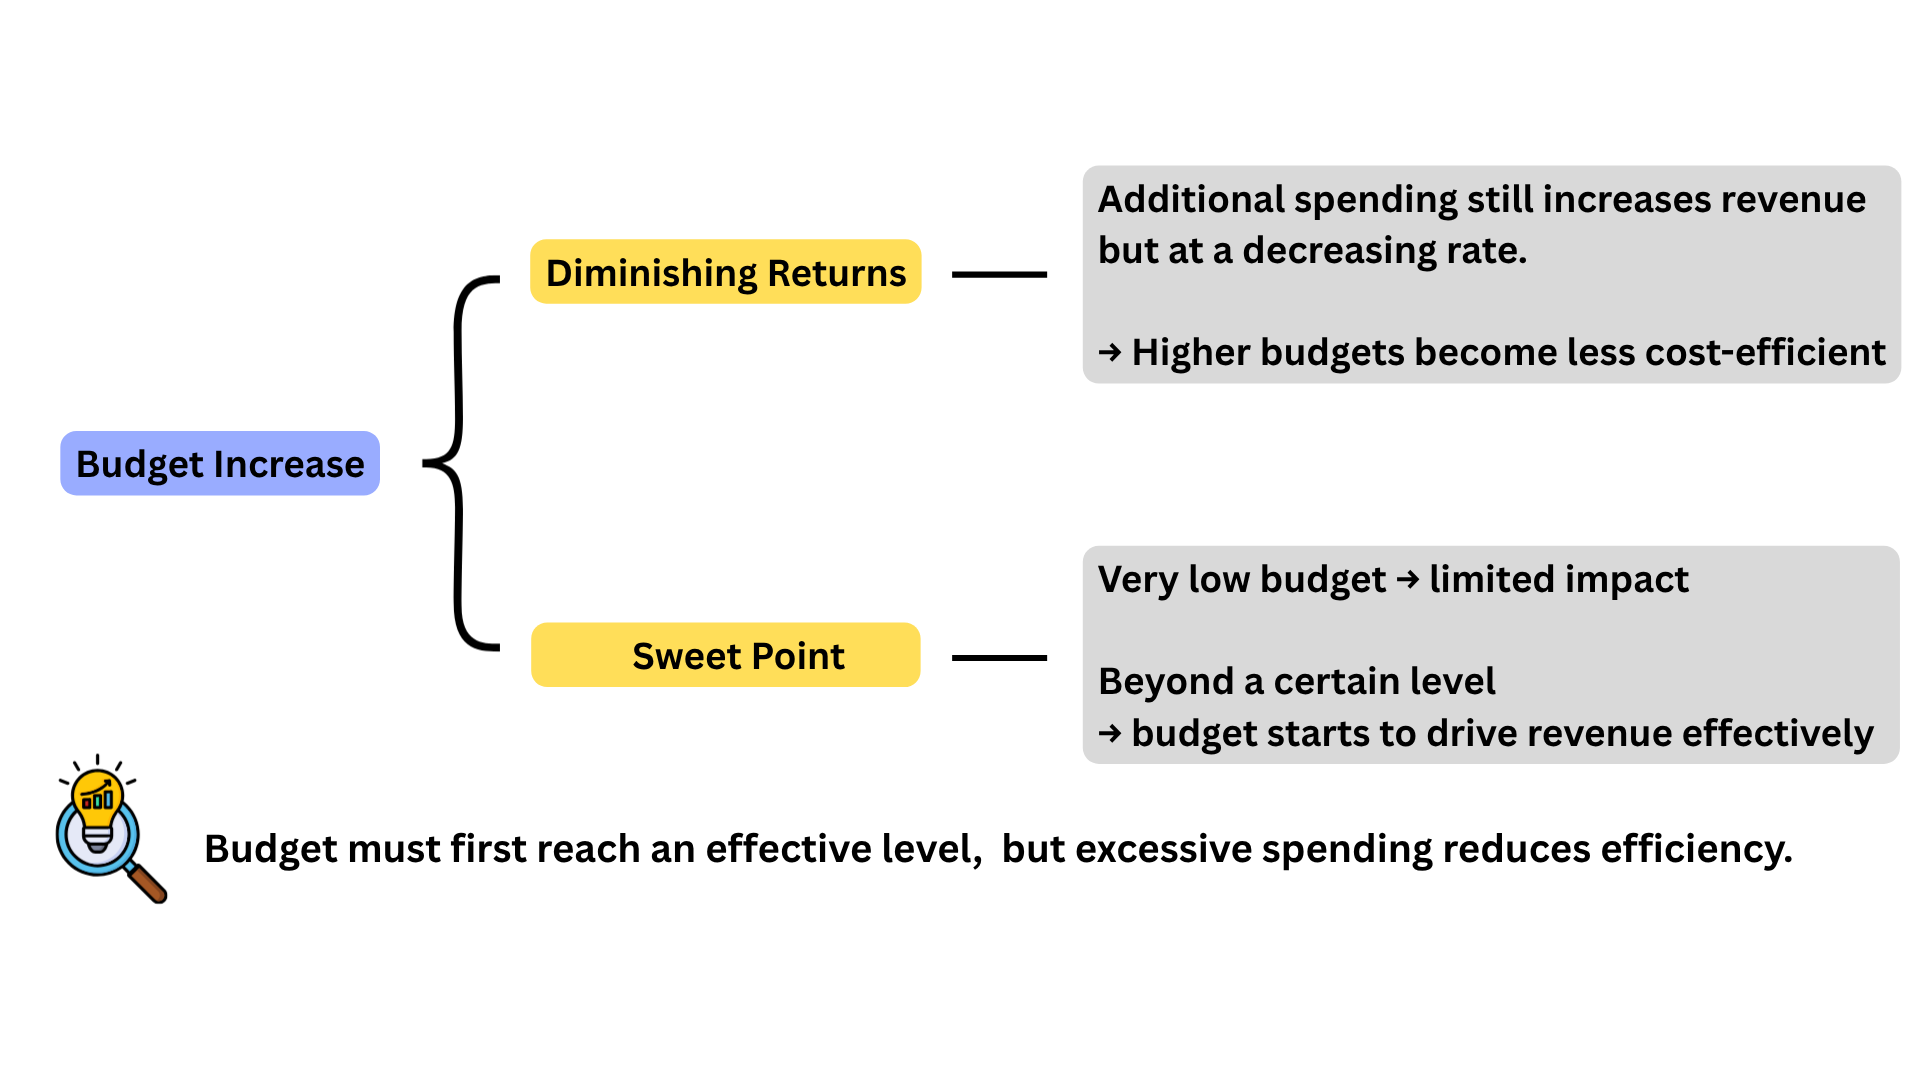

## **Possible Actions Based On Results (Act)**

Film producers and investors should **avoid simply increasing budgets**, as marginal returns diminish at higher spending levels. They should **focus on a budget level around the identified turning point** (≈ USD 1.8M), where beyond this point, additional investment becomes more effective. Meanwhile, **budget decisions** should **be adjusted** based on factors such as audience appeal and genre, as these also significantly influence box office revenue.

## **Final Reflection**

### **Considerations on Data Ethics**

While the analysis provides useful insights, several ethical issues should be noted. The dataset **may be biased** as the dataset may **overrepresent** certain types of productions, limiting generalisability. Reliance on quantitative metrics (e.g., revenue, ratings) **may oversimplify** success by **ignoring qualitative aspects** like artistic or cultural value. There is also a **risk of misinterpretation** if diminishing returns are applied **universally**. Therefore, results should inform, not dictate, decisions and be **interpreted with proper context**.

### **Considerations on Data Privacy**

Although the analysis uses publicly available data, privacy remains important. If **individual-level data** (audience rating) will be involved in the furture, it should be **anonymised to prevent identification**. Data collection should enusre **clear consent** and **transparency** on data usage.

### **Considerations on Security**

As current used data are open without any personal information, there are no special risks or measures to be taken to ensure data security when during the development of the data science question.